In [1]:
import pandas as pd
import numpy as np


policy = pd.read_csv("policy_sales_data.csv")

In [2]:
claim_amount = 100000 * 0.10

In [3]:
policy['Policy_Purchase_Date'] = pd.to_datetime(policy['Policy_Purchase_Date'])
policy['Policy_Start_Date'] = pd.to_datetime(policy['Policy_Start_Date'])

claim_days = [7,14,21,28]

claims_2025 = policy[
    policy['Policy_Purchase_Date'].dt.day.isin(claim_days)
].copy()

# 30% vehicles claim
claims_2025 = claims_2025.sample(frac=0.30, random_state=1)

claims_2025['Claim_Date'] = claims_2025['Policy_Start_Date']
claims_2025['Claim_Amount'] = claim_amount
claims_2025['Claim_Type'] = 1

In [4]:
four_year = policy[policy['Policy_Tenure'] == 4].copy()

claims_2026 = four_year.sample(frac=0.10, random_state=1)

date_range = pd.date_range(
    start="2026-01-01",
    end="2026-02-28"
)

claims_2026['Claim_Date'] = np.random.choice(date_range, len(claims_2026))
claims_2026['Claim_Amount'] = claim_amount
claims_2026['Claim_Type'] = 2

In [5]:
claims = pd.concat([claims_2025, claims_2026])

In [6]:
claims = claims.reset_index(drop=True)
claims['Claim_ID'] = claims.index + 1

In [7]:
claims_table = claims[
    ['Claim_ID','Customer_ID','Vehicle_ID',
     'Claim_Amount','Claim_Date','Claim_Type']
]

In [8]:
claims_table.to_csv("claims_data.csv", index=False)

In [10]:
claims_table.shape

(49212, 6)

In [15]:
claims_table.head(15)

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,1,C0369738,V0369738,10000.0,2025-02-20,1
1,2,C0174524,V0174524,10000.0,2025-04-28,1
2,3,C0198323,V0198323,10000.0,2025-05-14,1
3,4,C0789125,V0789125,10000.0,2025-06-14,1
4,5,C0332114,V0332114,10000.0,2025-10-28,1
5,6,C0843516,V0843516,10000.0,2025-04-28,1
6,7,C0950184,V0950184,10000.0,2025-08-21,1
7,8,C0456627,V0456627,10000.0,2025-09-28,1
8,9,C0463733,V0463733,10000.0,2025-07-14,1
9,10,C0874421,V0874421,10000.0,2025-08-07,1


In [16]:
import pandas as pd

policy = pd.read_csv("policy_sales_data.csv")
claims = pd.read_csv("claims_data.csv")

policy['Policy_Purchase_Date'] = pd.to_datetime(policy['Policy_Purchase_Date'])
claims['Claim_Date'] = pd.to_datetime(claims['Claim_Date'])

In [ ]:
#Calculate the total premium collected during the year 2024

In [17]:
total_premium = policy['Premium'].sum()
print(total_premium)

240120900


In [ ]:
# Calculate the total claim cost for each year (2025 and 2026) with a monthly breakdown.

In [18]:
claims['Year'] = claims['Claim_Date'].dt.year
claims['Month'] = claims['Claim_Date'].dt.month

monthly_claims = claims.groupby(['Year','Month'])['Claim_Amount'].sum()

print(monthly_claims)

Year  Month
2025  1        33130000.0
      2        32300000.0
      3        32570000.0
      4        33060000.0
      5        32180000.0
      6        33100000.0
      7        32650000.0
      8        32480000.0
      9        33030000.0
      10       32550000.0
      11       32540000.0
      12       32550000.0
2026  1        52510000.0
      2        47470000.0
Name: Claim_Amount, dtype: float64


In [ ]:
 #Calculate the claim cost to premium ratio for each policy tenure (1, 2, 3, and 4 years)

In [19]:
merged = pd.merge(policy, claims, on=['Customer_ID','Vehicle_ID'])

ratio = merged.groupby('Policy_Tenure').agg(
    total_premium=('Premium','sum'),
    total_claim=('Claim_Amount','sum')
)

ratio['claim_premium_ratio'] = ratio['total_claim'] / ratio['total_premium']

print(ratio)

               total_premium  total_claim  claim_premium_ratio
Policy_Tenure                                                 
1                     779900   77990000.0           100.000000
2                    2354200  117710000.0            50.000000
3                    4725300  157510000.0            33.333333
4                    5556400  138910000.0            25.000000


In [ ]:
 #Calculate the claim cost to premium ratio by the month in which the policy was sold(January–December 2024).


In [20]:
policy['Sale_Month'] = policy['Policy_Purchase_Date'].dt.month

merged = pd.merge(policy, claims, on=['Customer_ID','Vehicle_ID'])

month_ratio = merged.groupby('Sale_Month').agg(
    premium=('Premium','sum'),
    claim=('Claim_Amount','sum')
)

month_ratio['ratio'] = month_ratio['claim'] / month_ratio['premium']

print(month_ratio)

            premium       claim      ratio
Sale_Month                                
1           1138300  41710000.0  36.642361
2           1110800  40660000.0  36.604249
3           1124200  40870000.0  36.354741
4           1129000  41420000.0  36.687334
5           1116000  40820000.0  36.577061
6           1101100  40740000.0  36.999364
7           1134500  41320000.0  36.421331
8           1106900  40680000.0  36.751287
9           1133800  41530000.0  36.629035
10          1088400  40360000.0  37.081955
11          1104300  40780000.0  36.928371
12          1128500  41230000.0  36.535224


In [ ]:
# If every vehicle that has not yet made a claim eventually files exactly one claim during theremaining policy tenure, estimate the total potential claim liability.


In [21]:
claimed_vehicles = claims['Vehicle_ID'].unique()

remaining = policy[~policy['Vehicle_ID'].isin(claimed_vehicles)]

future_claim_liability = len(remaining) * 10000

print(future_claim_liability)

9511930000


In [ ]:
#  Assume daily premium = Total Premium ÷ Total Policy Tenure Days. Based on this:
# * Calculate the premium already earned by the company up to February 28, 2026.


In [22]:
policy['Policy_Start_Date'] = pd.to_datetime(policy['Policy_Start_Date'])

policy['daily_premium'] = policy['Premium'] / (policy['Policy_Tenure']*365)

cutoff = pd.to_datetime("2026-02-28")

policy['earned_days'] = (cutoff - policy['Policy_Start_Date']).dt.days
policy['earned_days'] = policy['earned_days'].clip(lower=0)

policy['earned_premium'] = policy['earned_days'] * policy['daily_premium']

total_earned = policy['earned_premium'].sum()

print(total_earned)

66148198.35616441


In [ ]:
#Build a simple dashboard or visualization showing claim trends by month.


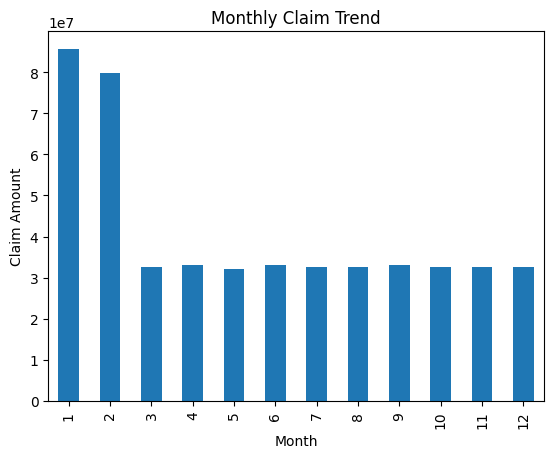

In [23]:
import matplotlib.pyplot as plt

claims['Month'] = claims['Claim_Date'].dt.month
monthly_claims = claims.groupby('Month')['Claim_Amount'].sum()

monthly_claims.plot(kind='bar')

plt.title("Monthly Claim Trend")
plt.xlabel("Month")
plt.ylabel("Claim Amount")

plt.show()

In [24]:
#Identify which policy tenure appears most profitable and explain why.


In [25]:
merged = pd.merge(policy, claims, on=['Customer_ID','Vehicle_ID'])

profit = merged.groupby('Policy_Tenure').agg(
    total_premium=('Premium','sum'),
    total_claim=('Claim_Amount','sum')
)

profit['profit'] = profit['total_premium'] - profit['total_claim']

print(profit)

               total_premium  total_claim       profit
Policy_Tenure                                         
1                     779900   77990000.0  -77210100.0
2                    2354200  117710000.0 -115355800.0
3                    4725300  157510000.0 -152784700.0
4                    5556400  138910000.0 -133353600.0


In [26]:
#Estimate the loss ratio (Claims ÷ Premium) for the portfolio.


In [27]:
total_claims = claims['Claim_Amount'].sum()
total_premium = policy['Premium'].sum()

loss_ratio = total_claims / total_premium

print(loss_ratio)

2.049467580706219


In [28]:
#If claim frequency increases by 5% annually, estimate the impact on future profitability

In [29]:
future_claims = total_claims * 1.05

future_loss_ratio = future_claims / total_premium

print(future_loss_ratio)

2.15194095974153
